# Logistic Regression

## AI/ML Engineer Training Program

**Notebook:** 02_Logistic_Regression.ipynb
**Phase:** Classification Models
**Objective:** Build a Logistic Regression classifier using an industry-standard machine learning workflow and understand why logistic regression performs classification despite being called regression.

### Learning Goals

By the end of this notebook, I should be able to:

* Explain the difference between Linear Regression and Logistic Regression.
* Understand the Sigmoid Function and probability-based classification.
* Build a Logistic Regression pipeline with feature scaling.
* Tune hyperparameters using GridSearchCV.
* Evaluate a classifier using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
* Explain Logistic Regression confidently in interviews.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (569, 30)
y shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Missing values:\n", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())

print("\nTarget distribution:")
print(y.value_counts())

Missing values:
 0
Duplicate rows: 0

Target distribution:
target
1    357
0    212
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


In [5]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [6]:
logistic_pipeline.fit(X_train, y_train)

y_pred = logistic_pipeline.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))

Accuracy: 0.9825

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [8]:
y_prob = logistic_pipeline.predict_proba(X_test)

print(y_prob[:5])

[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]


## Logistic Regression Probabilities

Logistic Regression predicts **class probabilities** before assigning a final class label.

`predict_proba()` returns:

* `P(class 0)` (Malignant)
* `P(class 1)` (Benign)

The final prediction is determined by the class with the higher probability, typically using a **0.5 decision threshold**.

This probabilistic output is one of the major advantages of Logistic Regression, making it highly useful in healthcare, finance, and risk prediction applications.


In [9]:
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]   # Probability of class 1 (Benign)

threshold = 0.7

y_pred_threshold = (y_prob >= threshold).astype(int)

print(classification_report(
    y_test,
    y_pred_threshold,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.89      0.98      0.93        42
      Benign       0.99      0.93      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



    ## Effect of Decision Threshold

The default decision threshold for Logistic Regression is **0.5**.

Increasing the threshold to **0.7** makes the model more conservative before predicting the positive class (Benign).

### Observation

* Overall accuracy decreased from **98.25% to 95.00%**.
* **Benign recall decreased** from **0.99 to 0.93**.
* **Malignant precision decreased** from **0.98 to 0.89**.
* **Malignant recall remained unchanged** at **0.98**.

### Engineering Interpretation

Raising the threshold caused the model to classify more patients as malignant, increasing false positives without improving malignant detection.

For this dataset, the default threshold of **0.5** provides a better balance between precision and recall.


In [10]:
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9954


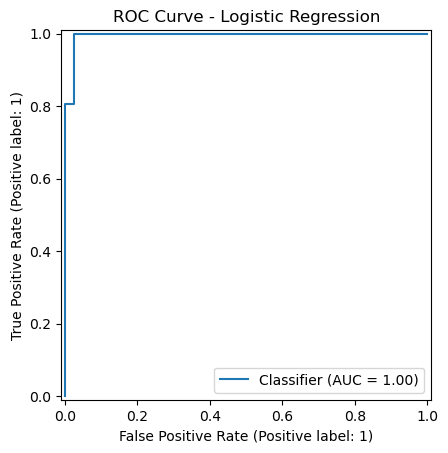

In [11]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve - Logistic Regression")
plt.show()

## ROC-AUC Evaluation

The Logistic Regression model achieved a **ROC-AUC score of 0.9954**, indicating excellent class-separation capability.

### Interpretation

A ROC-AUC score close to **1.0** means the model can distinguish malignant and benign tumors with extremely high confidence across a wide range of decision thresholds.

This metric is especially valuable in medical diagnosis because it evaluates the model independently of the default **0.5 classification threshold**.


In [12]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_pipeline.named_steps["model"].coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


## Feature Importance Through Coefficients

Logistic Regression provides a coefficient for every input feature.

### Interpretation

* **Negative coefficient:** Increasing the feature increases the probability of the **Malignant class (0)**.
* **Positive coefficient:** Increasing the feature increases the probability of the **Benign class (1)**.
* **Larger absolute coefficient:** Stronger influence on the prediction.

In this model, features such as **worst texture, radius error, worst concave points, and worst area** have the strongest negative influence, indicating that larger values are associated with a higher likelihood of malignant tumors.

This interpretability is a major advantage of Logistic Regression in medical and financial applications.


In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --------------------------------------------------
# Create Dataset
# --------------------------------------------------

data = {
    "Age": [25, 32, 47, 51, 23, 36],
    "Salary": [30000, 60000, 80000, 90000, 25000, 65000],
    "Gender": ["Male", "Female", "Male", "Female", "Male", "Female"],
    "City": ["Chennai", "Mumbai", "Delhi", "Chennai", "Delhi", "Mumbai"],
    "Buy": [0, 1, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

# --------------------------------------------------
# Features and Target
# --------------------------------------------------

X = df.drop("Buy", axis=1)
y = df["Buy"]

# --------------------------------------------------
# Train Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

# --------------------------------------------------
# Identify Column Types
# --------------------------------------------------

numeric_features = ["Age", "Salary"]
categorical_features = ["Gender", "City"]

# --------------------------------------------------
# Preprocessing
# --------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# --------------------------------------------------
# Pipeline
# --------------------------------------------------

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression())
    ]
)

# --------------------------------------------------
# Train
# --------------------------------------------------

pipeline.fit(X_train, y_train)

# --------------------------------------------------
# Predict
# --------------------------------------------------

y_pred = pipeline.predict(X_test)

print("Predictions:", y_pred.tolist())
print("Accuracy:", accuracy_score(y_test, y_pred))

Predictions: [0, 1]
Accuracy: 1.0


In [2]:
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print(feature_names)

['num__Age' 'num__Salary' 'cat__Gender_Female' 'cat__Gender_Male'
 'cat__City_Chennai' 'cat__City_Delhi' 'cat__City_Mumbai']


In [3]:
new_customer = pd.DataFrame({
    "Age": [30],
    "Salary": [55000],
    "Gender": ["Male"],
    "City": ["Mumbai"]
})

prediction = pipeline.predict(new_customer)
probability = pipeline.predict_proba(new_customer)

print("Prediction:", prediction[0])
print("Probability:", probability)

Prediction: 1
Probability: [[0.32070544 0.67929456]]
